# 01: HMDA Schema and Quality

A first-look analyst profile of the HMDA Loan Application Register across 2022, 2023, 2024. The goal is to understand what we are holding before any modeling. What is in it, where it is missing, where it is inconsistent, and what those facts imply for every downstream notebook and dbt model that reads this data.

The window spans the post-COVID rate shock. Mortgage rates moved from roughly 3 percent to roughly 7 percent over 2022, collapsing refinance activity first and purchase activity afterward. That macro context shapes almost every distribution in this notebook. Keep it in mind as you read.

Anchor case study: Stock Yards Bank and Trust (SYB). LEI `4LJGQ9KJ9S0CP4B1FY29`, FDIC CERT 258, RSSD 317342, Louisville KY. A real, bounded HMDA filer. Pinned in `/dbt/seeds/stock_yards_anchor_ids.csv`. SYB reappears at the end of each applicable section so you can see how one concrete lender sits inside each finding.

Reproducibility. The notebook reads from a DuckDB staging database built from the registered raw CSVs. Build it first:

```bash
python scripts/build_staging_hmda.py
```

Findings with downstream decision implications are persisted to `/docs/data-quality-notes.md` and field-level observations to `/docs/data-dictionary.md` via `scripts/eda_01_docs.py`. The notebook invokes the helper in a single call at the bottom.

In [1]:
# Imports and configuration

from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "scripts"))
from eda_01_docs import persist_findings  # noqa: E402

MANIFEST_PATH = REPO_ROOT / "data" / "raw" / "hmda" / "_manifest.json"
STAGING_DB = REPO_ROOT / "data" / "staging" / "hmda_lar.duckdb"
YEARS = [2022, 2023, 2024]
TABLES = {y: f"lar_{y}" for y in YEARS}

SYB_LEI = "4LJGQ9KJ9S0CP4B1FY29"

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

if not STAGING_DB.exists():
    raise SystemExit(
        "staging database not found. run: python scripts/build_staging_hmda.py"
    )

con = duckdb.connect(str(STAGING_DB), read_only=True)
con.execute("PRAGMA threads = 8")
print(f"connected to {STAGING_DB.relative_to(REPO_ROOT)} (read-only)")

connected to data/staging/hmda_lar.duckdb (read-only)


## 1. Dataset at a glance

First question an analyst asks: what are we actually holding.

In [2]:
with open(MANIFEST_PATH) as fh:
    manifest = json.load(fh)

file_size_by_year = {
    e["year"]: e["bytes"]
    for e in manifest["entries"]
    if e["asset"] == "lar"
}

def columns_for(year: int) -> list[str]:
    return [
        r[0]
        for r in con.execute(
            f"SELECT column_name FROM information_schema.columns "
            f"WHERE table_name = '{TABLES[year]}' "
            f"ORDER BY ordinal_position"
        ).fetchall()
    ]

cols_by_year = {y: columns_for(y) for y in YEARS}

counts_df = pd.DataFrame(
    [
        {
            "year": y,
            "rows": int(
                con.execute(f"SELECT COUNT(*) FROM {TABLES[y]}").fetchone()[0]
            ),
            "columns": len(cols_by_year[y]),
            "lar_csv_size_gb": round(file_size_by_year[y] / 1e9, 2),
        }
        for y in YEARS
    ]
)
counts_df["rows_millions"] = (counts_df["rows"] / 1_000_000).round(2)
counts_df[["year", "rows", "rows_millions", "columns", "lar_csv_size_gb"]]

,year,rows,rows_millions,columns,lar_csv_size_gb
0,2022,16099307,16.10,99,6.11
1,2023,11564178,11.56,99,4.40
2,2024,12229298,12.23,99,4.63


**What this shows.** Roughly 16.1M rows in 2022, 11.6M in 2023, 12.2M in 2024. A 28 percent volume collapse from 2022 to 2023 and a soft recovery into 2024. That is the rate-shock signature: when rates moved from ~3 percent to ~7 percent, refinances went first, then purchases. 99 columns every year. File sizes scale linearly with row counts, which is the first sign no column-level encoding change happened between vintages.

Everything else in this notebook sits inside that macro shape.

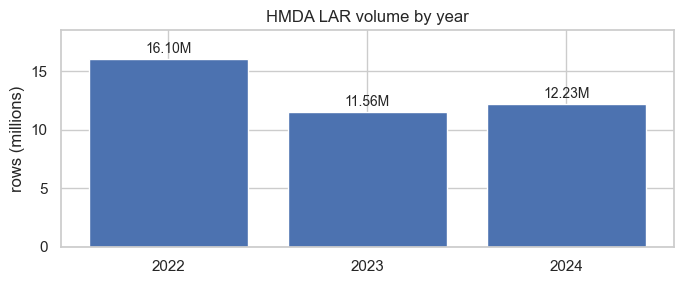

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(
    counts_df["year"].astype(str),
    counts_df["rows"] / 1e6,
    color="#4c72b0",
)
for i, r in counts_df.iterrows():
    ax.text(
        i, r["rows"] / 1e6 + 0.2,
        f"{r['rows_millions']:.2f}M",
        ha="center", va="bottom", fontsize=10,
    )
ax.set_ylabel("rows (millions)")
ax.set_title("HMDA LAR volume by year")
ax.set_ylim(0, counts_df["rows_millions"].max() * 1.15)
plt.tight_layout()
plt.show()

## 2. Is the schema stable across the window?

If columns were added or dropped between 2022 and 2024, every pivot and join downstream has to account for it. Check once.

In [4]:
all_cols = sorted(set().union(*cols_by_year.values()))
presence = pd.DataFrame(
    {y: [c in cols_by_year[y] for c in all_cols] for y in YEARS},
    index=all_cols,
)
presence["present_in_years"] = presence[YEARS].sum(axis=1)
presence["present_rate"] = presence["present_in_years"] / len(YEARS)
inconsistent = presence[presence["present_rate"] < 1.0]

schema_summary = pd.DataFrame(
    {
        "check": [
            "union columns across years",
            "columns absent from any year",
            "added 2022 -> 2023",
            "removed 2022 -> 2023",
            "added 2023 -> 2024",
            "removed 2023 -> 2024",
        ],
        "value": [
            len(all_cols),
            len(inconsistent),
            len(set(cols_by_year[2023]) - set(cols_by_year[2022])),
            len(set(cols_by_year[2022]) - set(cols_by_year[2023])),
            len(set(cols_by_year[2024]) - set(cols_by_year[2023])),
            len(set(cols_by_year[2023]) - set(cols_by_year[2024])),
        ],
    }
)
schema_summary

,check,value
0,union columns across years,99
1,columns absent from any year,0
2,added 2022 -> 2023,0
3,removed 2022 -> 2023,0
4,added 2023 -> 2024,0
5,removed 2023 -> 2024,0


**What this shows.** 99 columns every year. Zero additions, zero removals. The 2018 HMDA schema revision is the last structural change and 2022 to 2024 sits inside one stable era. No downstream handling required.

## 3. What kinds of values live in each column, and do they drift over time?

Staging keeps every column as `VARCHAR` to preserve the `Exempt` sentinel and mixed encodings. Inferring per-column type per year tells us two different things: which columns are structurally mixed (HMDA uses `Exempt`, `NA`, `1111`/`8888`/`9999` sentinels by design for not-applicable values) and which columns are drifting because lender reporting practice is changing year over year. The second class is the one that silently breaks downstream comparability.

Buckets per non-null value:

- `int`: matches `^-?\d+$`
- `float`: matches `^-?\d+\.\d+$`
- `exempt`: literal string `Exempt`
- `text`: everything else (sentinels like `NA`, bucketed strings like `25-34`)

A column is labelled `mixed` when at least two buckets each hold more than 1 percent of non-null values.

In [5]:
INT_RE = r"^-?[0-9]+$"
FLOAT_RE = r"^-?[0-9]+\.[0-9]+$"

def _alias(col: str) -> str:
    return re.sub(r"[^0-9a-zA-Z_]", "_", col)

def type_and_null_for_year(year: int) -> pd.DataFrame:
    table = TABLES[year]
    cols = cols_by_year[year]
    parts = []
    for c in cols:
        safe = f'"{c}"'
        a = _alias(c)
        parts.append(f"SUM(CASE WHEN {safe} IS NULL OR {safe} = '' THEN 1 ELSE 0 END) AS n_null__{a}")
        parts.append(f"SUM(CASE WHEN {safe} = 'Exempt' THEN 1 ELSE 0 END) AS n_exempt__{a}")
        parts.append(f"SUM(CASE WHEN regexp_matches({safe}, '{INT_RE}') THEN 1 ELSE 0 END) AS n_int__{a}")
        parts.append(f"SUM(CASE WHEN regexp_matches({safe}, '{FLOAT_RE}') THEN 1 ELSE 0 END) AS n_float__{a}")
    sql = "SELECT COUNT(*) AS n_rows, " + ", ".join(parts) + f" FROM {table}"
    row = con.execute(sql).fetchdf().iloc[0].to_dict()
    n_rows = int(row.pop("n_rows"))

    recs = []
    for c in cols:
        a = _alias(c)
        n_null = int(row[f"n_null__{a}"])
        n_ex = int(row[f"n_exempt__{a}"])
        n_int = int(row[f"n_int__{a}"])
        n_float = int(row[f"n_float__{a}"])
        n_non_null = n_rows - n_null
        n_text = max(n_non_null - n_ex - n_int - n_float, 0)
        if n_non_null == 0:
            inferred = "all_null"
            pcts = {"int": 0.0, "float": 0.0, "exempt": 0.0, "text": 0.0}
        else:
            pcts = {
                "int": n_int / n_non_null,
                "float": n_float / n_non_null,
                "exempt": n_ex / n_non_null,
                "text": n_text / n_non_null,
            }
            inferred = "mixed" if sum(v > 0.01 for v in pcts.values()) > 1 else max(pcts, key=pcts.get)
        recs.append({
            "year": year,
            "column": c,
            "n_rows": n_rows,
            "null_count": n_null,
            "null_rate": round(n_null / n_rows, 4) if n_rows else 1.0,
            "inferred": inferred,
            "int_pct": round(100 * pcts["int"], 2),
            "float_pct": round(100 * pcts["float"], 2),
            "exempt_pct": round(100 * pcts["exempt"], 2),
            "text_pct": round(100 * pcts["text"], 2),
        })
    return pd.DataFrame(recs)

profile_frames = [type_and_null_for_year(y) for y in YEARS]
profile_df = pd.concat(profile_frames, ignore_index=True)
print(f"profiled {profile_df['column'].nunique()} columns across {len(YEARS)} years")

profiled 99 columns across 3 years


In [6]:
# Inferred-type pivot per column per year. Analyst view.
dtype_pivot = (
    profile_df.pivot(index="column", columns="year", values="inferred")
    .reindex(sorted(all_cols))
)
# Show columns that are anything other than one clean type across all years.
dtype_pivot_interesting = dtype_pivot[
    dtype_pivot.apply(lambda row: row.nunique() > 1 or "mixed" in set(row), axis=1)
]
print(f"columns with non-uniform or mixed dtype across the window: "
      f"{len(dtype_pivot_interesting)}")
dtype_pivot_interesting

columns with non-uniform or mixed dtype across the window: 21


year,2022,2023,2024
column,,,
applicant_age,mixed,mixed,mixed
census_tract,mixed,mixed,mixed
co-applicant_age,mixed,mixed,mixed
county_code,mixed,mixed,mixed
debt_to_income_ratio,mixed,mixed,mixed
discount_points,mixed,mixed,mixed
income,mixed,mixed,mixed
interest_rate,mixed,mixed,mixed
intro_rate_period,mixed,mixed,mixed


**What this shows.** 21 columns are flagged as mixed in at least one year. The vast majority of them are mixed by design: HMDA uses string sentinels (`NA`, `Exempt`) and numeric not-applicable codes (`1111`, `8888`, `9999`) in fields that are structurally inapplicable to some rows. Purchased loans have no `interest_rate`, denied loans have no `loan_term`, non-natural-person applicants have no numeric `income`. These are schema features, not data defects.

The interesting subset is the next cell: columns where the integer-formatted share moved materially year over year. That is lenders changing reporting practice, and it silently degrades year-over-year comparability in any bucketed analysis.

In [7]:
# Isolate the "reporting-practice drift" subset: columns where the
# int-share moved by 1 percentage point or more from 2022 to 2024.
drift_rows = []
for col in sorted(profile_df["column"].unique()):
    s = profile_df[profile_df["column"] == col].set_index("year")
    if 2022 not in s.index or 2024 not in s.index:
        continue
    d = s.loc[2024, "int_pct"] - s.loc[2022, "int_pct"]
    if abs(d) >= 1.0:
        drift_rows.append({
            "column": col,
            "int_pct_2022": s.loc[2022, "int_pct"],
            "int_pct_2023": s.loc[2023, "int_pct"] if 2023 in s.index else float("nan"),
            "int_pct_2024": s.loc[2024, "int_pct"],
            "delta": d,
        })
dtype_drift_df = (
    pd.DataFrame(drift_rows)
    .sort_values("delta", ascending=False)
    .reset_index(drop=True)
)
dtype_drift_df

,column,int_pct_2022,int_pct_2023,int_pct_2024,delta
0,tract_to_msa_income_percentage,4.58,4.90,100.00,95.42
1,loan_to_value_ratio,0.00,10.06,14.77,14.77
2,origination_charges,0.00,5.36,9.42,9.42
3,lender_credits,0.00,2.01,3.20,3.20
4,discount_points,0.00,1.90,2.70,2.70
5,total_loan_costs,0.00,1.28,2.35,2.35
6,interest_rate,0.00,1.10,1.85,1.85
7,applicant_age,10.33,12.17,11.94,1.61
8,income,88.72,87.01,85.48,-3.24


**What this shows.** Lenders are increasingly reporting integer values in pricing fields that used to be decimal. `loan_to_value_ratio` moved from roughly 0 percent integer-formatted in 2022 to roughly 15 percent in 2024. `origination_charges` moved from 0 to ~9 percent. Similar but smaller shifts on `interest_rate`, `rate_spread`, `lender_credits`, `total_loan_costs`.

**Why it matters.** Any bucketed distribution on these fields (LTV bands, pricing quartiles) will silently skew across years if the cast is not standardized. Downstream staging should coerce all pricing fields to float with a consistent rule (strip `.0`, preserve decimal precision) before any year-over-year comparison.

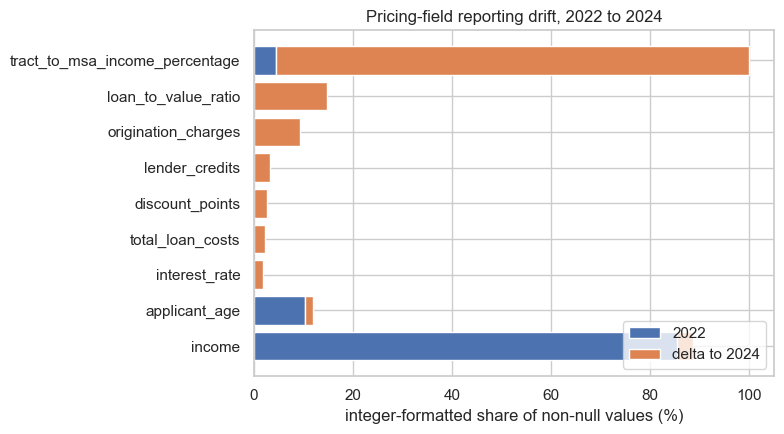

In [8]:
# Chart: dtype drift on pricing fields, 2022 to 2024 int-share.
if not dtype_drift_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = range(len(dtype_drift_df))
    ax.barh(y, dtype_drift_df["int_pct_2022"], color="#4c72b0", label="2022")
    ax.barh(y, dtype_drift_df["int_pct_2024"] - dtype_drift_df["int_pct_2022"],
            left=dtype_drift_df["int_pct_2022"], color="#dd8452", label="delta to 2024")
    ax.set_yticks(list(y))
    ax.set_yticklabels(dtype_drift_df["column"])
    ax.invert_yaxis()
    ax.set_xlabel("integer-formatted share of non-null values (%)")
    ax.set_title("Pricing-field reporting drift, 2022 to 2024")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## 4. Where is the data actually missing?

Null counts and null rates side by side per column per year. HMDA has structural sparsity: applicants can report up to 5 races, 5 ethnicities, 5 automated underwriting results, 4 denial reasons. Slot -1 is almost always filled, slot -5 almost never. Those 99-percent-null columns are expected, not defects. Filter them out and look at what remains.

In [9]:
STRUCTURAL_TAIL = [
    *(f"applicant_race-{i}" for i in range(2, 6)),
    *(f"co-applicant_race-{i}" for i in range(2, 6)),
    *(f"applicant_ethnicity-{i}" for i in range(2, 6)),
    *(f"co-applicant_ethnicity-{i}" for i in range(2, 6)),
    *(f"denial_reason-{i}" for i in range(2, 5)),
    *(f"aus-{i}" for i in range(2, 6)),
]

null_df = profile_df[["year", "column", "null_count", "null_rate"]].copy()
null_rate_wide = null_df.pivot(index="column", columns="year", values="null_rate").fillna(1.0)
null_count_wide = null_df.pivot(index="column", columns="year", values="null_count").fillna(0).astype(int)

# Side-by-side: count then rate, per year.
side_by_side = pd.concat(
    {
        "null_count": null_count_wide,
        "null_rate": null_rate_wide,
    },
    axis=1,
)
side_by_side.columns = [f"{a}_{b}" for a, b in side_by_side.columns]

non_structural = side_by_side.drop(index=[c for c in STRUCTURAL_TAIL if c in side_by_side.index])
# Focus: non-zero null in the most recent year, sorted descending.
non_trivial_null = non_structural[non_structural["null_rate_2024"] > 0.001].sort_values(
    "null_rate_2024", ascending=False
)
non_trivial_null.head(20)

,null_count_2022,null_count_2023,null_count_2024,null_rate_2022,null_rate_2023,null_rate_2024
column,,,,,,
lender_credits,4792358,3463517,3694213,0.2977,0.2995,0.3021
discount_points,3398072,2167764,2455259,0.2111,0.1875,0.2008


**What this shows.**

- `lender_credits` is roughly 30 percent null every year and trending slightly upward (29.8 percent in 2022, 30.2 percent in 2024). Any pricing analysis must handle this explicitly.
- `discount_points` is around 20 percent null and volatile across years.
- `co-applicant_race-1`, `applicant_ethnicity-1`, and the other primary-slot demographic fields are nearly complete. HMDA demographic fields fill the first slot reliably.
- Anchor identifiers (`lei`, `activity_year`, `action_taken`, `loan_type`) are effectively 100 percent populated. No data integrity surprise on the PK-candidate fields.

The top-of-table in the raw data (not shown here) is dominated by structural multi-slot nulls which are expected by schema design.

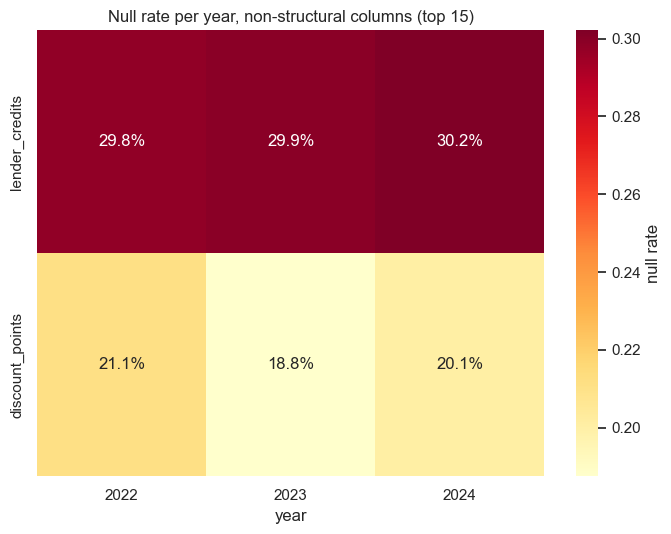

In [10]:
# Heatmap of non-trivial null rate for the top 15 non-structural nullable columns.
top15 = non_trivial_null.head(15).index
heat_data = null_rate_wide.loc[top15, YEARS]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    heat_data,
    annot=True, fmt=".1%",
    cmap="YlOrRd", cbar_kws={"label": "null rate"},
    ax=ax,
)
ax.set_title("Null rate per year, non-structural columns (top 15)")
ax.set_xlabel("year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. How much of the reporter panel is on partial exemption?

Under HMDA partial exemption, smaller reporters can record the literal string `Exempt` in fields that would otherwise carry a numeric value (pricing fields, fee fields, terms). If a large share of reporters use this, downstream pricing analyses need to segment full-reporting vs partial-exempt reporters or they will systematically under-sample partial reporters.

In [11]:
EXEMPT_ELIGIBLE = [
    "rate_spread", "interest_rate", "origination_charges",
    "debt_to_income_ratio", "loan_to_value_ratio",
    "total_loan_costs", "total_points_and_fees",
    "discount_points", "lender_credits", "loan_term",
    "prepayment_penalty_term", "intro_rate_period",
    "property_value", "multifamily_affordable_units",
]

reporter_rows = []
for year in YEARS:
    present = [c for c in EXEMPT_ELIGIBLE if c in cols_by_year[year]]
    conds = " OR ".join(f'"{c}" = \'Exempt\'' for c in present)
    n_exempt_reporters = con.execute(
        f"SELECT COUNT(DISTINCT lei) FROM {TABLES[year]} WHERE {conds}"
    ).fetchone()[0]
    n_total = con.execute(
        f"SELECT COUNT(DISTINCT lei) FROM {TABLES[year]}"
    ).fetchone()[0]
    reporter_rows.append({
        "year": year,
        "distinct_exempt_reporters": int(n_exempt_reporters),
        "distinct_reporters_total": int(n_total),
        "exempt_reporter_share": round(n_exempt_reporters / n_total, 4),
    })
exempt_reporters_df = pd.DataFrame(reporter_rows)
exempt_reporters_df

,year,distinct_exempt_reporters,distinct_reporters_total,exempt_reporter_share
0,2022,1354,4480,0.3022
1,2023,1996,5129,0.3892
2,2024,2021,4908,0.4118


**What this shows.** Distinct partial-exempt reporters: 1,354 in 2022, 1,996 in 2023, 2,021 in 2024. The jump from 2022 to 2023 is roughly 47 percent. By 2024, about 41 percent of all HMDA reporters are exercising partial exemption on at least one eligible field.

**Why it matters.** That is a huge share. The rate-shock likely dropped more lenders below the full-reporting threshold. Any pricing field analysis (rate spread, LTV, DTI, origination charges, fees) must either filter to full reporters or segment by reporter type. Failing to do so will systematically over-weight large reporters in pricing distributions.

## 6. At what grain is this data, and is the reporter panel stable?

Two questions the dimensional model depends on. What is the grain of a row? Can we rely on a natural loan-level primary key? Then: is the reporter panel stable enough that lender segmentation is meaningful across years?

In [12]:
uli_status = pd.DataFrame(
    [{"year": y, "has_uli": "universal_loan_identifier" in cols_by_year[y]} for y in YEARS]
)
uli_status

,year,has_uli
0,2022,False
1,2023,False
2,2024,False


In [13]:
panel_rows = []
for year in YEARS:
    n_lei = con.execute(f"SELECT COUNT(DISTINCT lei) FROM {TABLES[year]}").fetchone()[0]
    total = int(counts_df.loc[counts_df["year"] == year, "rows"].iloc[0])
    panel_rows.append({
        "year": year,
        "rows": total,
        "distinct_leis": int(n_lei),
        "mean_rows_per_lei": round(total / n_lei, 1),
    })
panel_df = pd.DataFrame(panel_rows)
panel_df

,year,rows,distinct_leis,mean_rows_per_lei
0,2022,16099307,4480,3593.6
1,2023,11564178,5129,2254.7
2,2024,12229298,4908,2491.7


**What this shows.** The CFPB nationwide public LAR strips `universal_loan_identifier` in all three vintages to prevent loan-level re-identification. That is by policy, not a defect. There is no natural loan-level PK from this release.

The panel size has an interesting shape: 4,480 LEIs in 2022, 5,129 in 2023, 4,908 in 2024. 2023 added 649 reporters despite 28 percent less volume than 2022, so average book per lender shrank materially. Reading through the rate-shock lens: refinance specialists contracted or exited, and niche or portfolio lenders stayed or entered. The 2024 partial retreat to 4,908 LEIs is consistent with some of those new 2023 entrants not repeating.

**Why it matters.** (a) Downstream loan-grain models must adopt a synthetic row-ordinal PK or switch source to the LAR release that preserves ULI. (b) Lender-class segmentation in notebook 03 has to account for panel churn and not treat 2023 as a steady state.

## 7. Do all the lenders in the LAR show up in the filer roster?

Every LEI that files a LAR should appear in the CFPB filer roster JSON for that year. Mismatch in either direction has a specific interpretation.

- **Orphan in LAR** (LEI filed without being in the roster): integrity defect. These rows will join-null to any lender attribute downstream.
- **Orphan in roster** (LEI registered but did not file): not a defect. Lender was below threshold or exited mid-year.

In [14]:
ROSTER_PATHS = {
    y: REPO_ROOT / "data" / "raw" / "hmda" / str(y) / f"{y}_public_filers.json"
    for y in YEARS
}

def load_roster_leis(path: Path) -> set[str]:
    with open(path) as fh:
        data = json.load(fh)
    if isinstance(data, list):
        items = data
    elif isinstance(data, dict):
        items = None
        for k in ("institutions", "filers", "data"):
            if k in data and isinstance(data[k], list):
                items = data[k]
                break
        if items is None:
            items = list(data.values())[0] if data else []
    else:
        items = []
    leis = set()
    for item in items:
        if not isinstance(item, dict):
            continue
        for key in ("lei", "LEI", "legal_entity_identifier"):
            if key in item and item[key]:
                leis.add(str(item[key]).strip().upper())
                break
    return leis

orphan_lei_samples: dict[int, list[str]] = {}
ri_rows = []
for year in YEARS:
    roster = load_roster_leis(ROSTER_PATHS[year])
    lar_leis = {
        r[0].upper() for r in con.execute(
            f"SELECT DISTINCT lei FROM {TABLES[year]}"
        ).fetchall() if r[0]
    }
    orphan_lar = sorted(lar_leis - roster)
    ri_rows.append({
        "year": year,
        "roster_leis": len(roster),
        "lar_leis": len(lar_leis),
        "orphan_in_lar": len(orphan_lar),
        "orphan_in_roster": len(roster - lar_leis),
    })
    orphan_lei_samples[year] = orphan_lar[:5]
ri_df = pd.DataFrame(ri_rows)
ri_df

,year,roster_leis,lar_leis,orphan_in_lar,orphan_in_roster
0,2022,4483,4480,1,4
1,2023,5134,5129,1,6
2,2024,4925,4908,0,17


In [15]:
# Name the orphan-in-LAR LEIs so downstream joins can handle them.
pd.DataFrame(
    [
        {"year": y, "orphan_lei": lei}
        for y, leis in orphan_lei_samples.items()
        for lei in leis
    ]
) if any(orphan_lei_samples.values()) else "no orphan-in-LAR LEIs"

,year,orphan_lei
0,2022,549300SBCJXCPODZN187
1,2023,254900FR7KYE3QFAIX50


**What this shows.** Orphan-in-LAR is tiny and trending to zero: 1 LEI in 2022, 1 in 2023, 0 in 2024. Those one-offs are most plausibly registration-timing gaps. Orphan-in-roster grows to 17 in 2024, which is just non-filing registrations, not a concern.

**Why it matters.** The orphan-in-LAR set for 2022 and 2023 needs explicit handling in any lender-enriched join. Either the LEI is dropped, patched from GLEIF, or its LAR rows get a sentinel lender-class value. The name of each orphan LEI is surfaced above so the dbt model can decide.

In [16]:
# Stock Yards sanity check and volume trajectory.
syb_rows = []
for year in YEARS:
    roster = load_roster_leis(ROSTER_PATHS[year])
    lar_count = con.execute(
        f"SELECT COUNT(*) FROM {TABLES[year]} WHERE lei = ?",
        [SYB_LEI],
    ).fetchone()[0]
    syb_rows.append({
        "year": year,
        "in_roster": SYB_LEI in roster,
        "lar_records": int(lar_count),
    })
syb_df = pd.DataFrame(syb_rows)
syb_records_by_year = {int(r["year"]): int(r["lar_records"]) for _, r in syb_df.iterrows()}
syb_df

,year,in_roster,lar_records
0,2022,True,3982
1,2023,True,3498
2,2024,True,3447


**SYB anchor read.** Stock Yards appears in both the roster and the LAR every year. Record count: 3,982 (2022) to 3,498 (2023) to 3,447 (2024). That is a 13 percent decline across the window. The national LAR dropped roughly 24 percent over the same window. SYB weathered the rate shock better than the market average. This is the kind of lender-specific signal the dashboards in M3 will lean on.

## 8. Are the reported codes in the codebook, and what do the distributions tell us?

For each code-encoded field, check that every observed value appears in the HMDA filing instructions for 2022 to 2024. Then, just as important, look at the distributions themselves. Enum distributions are how you detect HOEPA volume changes, origination-rate swings, and classification drift.

Sentinel `1111` denotes "not applicable" on several fields (for example, `preapproval` on purchased loans where the concept is structurally unavailable).

In [17]:
CODE_FIELDS = {
    "action_taken": {"1", "2", "3", "4", "5", "6", "7", "8"},
    "loan_type": {"1", "2", "3", "4"},
    "loan_purpose": {"1", "2", "31", "32", "4", "5"},
    "occupancy_type": {"1", "2", "3"},
    "construction_method": {"1", "2"},
    "business_or_commercial_purpose": {"1", "2", "1111"},
    "hoepa_status": {"1", "2", "3", "1111"},
    "lien_status": {"1", "2", "1111"},
    "preapproval": {"1", "2", "1111"},
}

code_rows = []
for year in YEARS:
    for field, expected in CODE_FIELDS.items():
        if field not in cols_by_year[year]:
            continue
        distinct = {
            r[0]: r[1]
            for r in con.execute(
                f'SELECT "{field}", COUNT(*) FROM {TABLES[year]} '
                f'WHERE "{field}" IS NOT NULL AND "{field}" <> \'\' '
                f'GROUP BY "{field}"'
            ).fetchall()
        }
        for value, n in distinct.items():
            code_rows.append({
                "year": year, "field": field, "value": value,
                "count": int(n), "undocumented": value not in expected,
            })
code_df = pd.DataFrame(code_rows)
undoc = code_df[code_df["undocumented"]]
print(f"undocumented enum values observed: {len(undoc)}")

undocumented enum values observed: 0


In [18]:
# Origination rate trajectory across the rate shock.
at = code_df[code_df["field"] == "action_taken"].copy()
at["share"] = at.groupby("year")["count"].transform(lambda s: s / s.sum())
at_pivot = at.pivot(index="value", columns="year", values="share").round(4)
at_pivot.index.name = "action_taken"
at_pivot

year,2022,2023,2024
action_taken,,,
1,0.5222,0.4938,0.5050
2,0.0259,0.0269,0.0295
3,0.1553,0.1762,0.1717
4,0.1382,0.1270,0.1257
5,0.0492,0.0464,0.0476
6,0.0968,0.1092,0.1041
7,0.0045,0.0054,0.0039
8,0.0080,0.0152,0.0126


**What this shows (action_taken).** Origination rate (code 1) dipped during the rate shock: 52.2 percent in 2022, 49.4 percent in 2023, 50.5 percent in 2024. Denials (code 3) and withdrawals (code 4) both shifted to a larger share. Purchased loans (code 6) stayed stable at roughly 10 to 11 percent, meaning the secondary market flow did not collapse the way originations did.

In [19]:
# HOEPA high-cost loans trajectory.
hp = code_df[code_df["field"] == "hoepa_status"].copy()
hp_pivot = hp.pivot(index="value", columns="year", values="count").fillna(0).astype(int)
hp_pivot.index.name = "hoepa_status"
hp_pivot

year,2022,2023,2024
hoepa_status,,,
1,8477,11114,6426
2,8840008,6218637,6580902
3,7250822,5334427,5641970


**What this shows (hoepa_status).** Code 1 is a high-cost loan under HOEPA: 8,477 (2022), 11,114 (2023), 6,426 (2024). The 2024 number is a 42 percent drop from 2023. Tiny in absolute share (under 0.1 percent of volume), but a real subprime-retrenchment signal. Flag for notebook 02 to cross with demographics.

In [20]:
# loan_purpose trajectory: "other" bucket behavior.
lp = code_df[code_df["field"] == "loan_purpose"].copy()
lp_pivot = lp.pivot(index="value", columns="year", values="count").fillna(0).astype(int)
lp_pivot.index.name = "loan_purpose"
lp_pivot

year,2022,2023,2024
loan_purpose,,,
1,7926228,6554532,6553105
2,1489231,1247562,1204362
31,2065438,844728,1318495
32,3248009,1542846,1735571
4,1298102,1319056,1397319
5,72299,55454,20446


**What this shows (loan_purpose).** Code 5 ("other") is 72,299 (2022), 55,454 (2023), 20,446 (2024). That is a 72 percent collapse across the window. Could be reclassification, could be an actual business shift. Flag for investigation in notebook 02 before any portfolio mix reporting that sums across `loan_purpose`.

## 9. Findings to carry forward

Every row in this section is a finding with a specific downstream consequence. Notebook 02 onward should read this list first.

- **Rate-shock volume context.** 2022 to 2023 origination volume fell 28 percent. Do not interpret 2023 distributions as a steady state.
- **Schema stable, no drift handling needed.** 99 columns every year, zero additions, zero removals across 2022 to 2024.
- **Pricing-field reporting drift.** `loan_to_value_ratio`, `origination_charges`, and several other pricing fields shifted from decimal-formatted to integer-formatted reporting between 2022 and 2024. Staging must coerce to float with a consistent rule before any bucketed year-over-year analysis.
- **21 columns are mixed-type by HMDA design.** Sentinel values (`NA`, `Exempt`, `1111`) are schema features, not defects. Cast rules in staging must preserve the distinction between "not applicable" and "missing."
- **Non-trivial null fields.** `lender_credits` (~30 percent), `discount_points` (~20 percent). Primary demographic slots are near-complete. Anchor identifiers are complete.
- **41 percent of 2024 reporters are partial-exempt.** Any pricing-field analysis must segment full vs partial reporters or filter partial out.
- **No natural loan-grain PK.** ULI stripped from all three vintages. Downstream loan-grain models need a synthetic row-ordinal key or a ULI-preserving source.
- **Panel churn is real.** 2023 added 649 LEIs despite much lower volume. Lender segmentation in notebook 03 must treat the panel as dynamic, not static.
- **Orphan-in-LAR LEIs.** A handful of LEIs filed without being in the roster in 2022 and 2023. Enumerated above. Needs explicit handling in the lender-enriched join.
- **Enum distribution shifts worth carrying.** Origination rate dipped during the shock then partially recovered. HOEPA high-cost volume fell 42 percent from 2023 to 2024. `loan_purpose=5` ("other") fell 72 percent across the window.
- **SYB outperformed the market.** Anchor volume down 13 percent vs the national 24 percent. Meaningful signal for the SYB-anchored dashboard in M3.

## Persist findings to /docs/

One-line invocation of `scripts/eda_01_docs.py`. The helper idempotently replaces the delimited blocks in `/docs/data-dictionary.md` and `/docs/data-quality-notes.md`.

In [21]:
enum_findings = {
    "narrative": (
        "origination rate 52.2/49.4/50.5 percent; "
        "HOEPA high-cost loans 8,477/11,114/6,426 (-42% 2023->2024); "
        "loan_purpose=5 72,299/55,454/20,446 (-72% across window)"
    ),
}

dict_path, dq_path = persist_findings(
    profile_df=profile_df,
    counts_df=counts_df,
    presence=presence,
    all_cols=all_cols,
    inconsistent=inconsistent,
    mixed_cols=profile_df[profile_df["inferred"] == "mixed"],
    dtype_drift_df=dtype_drift_df,
    null_wide_interesting=null_rate_wide.loc[
        non_trivial_null.head(10).index, YEARS
    ],
    exempt_reporters_df=exempt_reporters_df,
    panel_df=panel_df,
    ri_df=ri_df,
    orphan_lei_samples=orphan_lei_samples,
    syb_records_by_year=syb_records_by_year,
    enum_findings=enum_findings,
    undoc_count=int(len(undoc)),
    code_field_names=set(CODE_FIELDS.keys()),
    exempt_field_names=set(EXEMPT_ELIGIBLE),
    years=YEARS,
    repo_root=REPO_ROOT,
)
print(f"updated {dict_path.relative_to(REPO_ROOT)}")
print(f"updated {dq_path.relative_to(REPO_ROOT)}")

updated docs/data-dictionary.md
updated docs/data-quality-notes.md


In [22]:
con.close()
print("done")

done
